# FIFA World Cup Prediction Model
## Notebook 02 — Feature Engineering

**Goal:** Build ELO ratings from match history, then construct the full feature matrix used for training.

### What we build here
| Feature group | Description |
|---|---|
| ELO ratings | Team strength score updated after every match |
| Recent form | Points per game, goals scored/conceded in last 10 matches |
| Head-to-head | Historical win rate between the two teams |
| Match context | Neutral venue flag, tournament importance weight |


In [5]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.utils import data_path, output_path, get_logger
from src.elo import EloSystem
from src.features import build_features, FEATURE_COLS

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

logger = get_logger('02_features')
print('Imports OK ✓')


Imports OK ✓


## 1. Load processed match data

In [6]:
matches = pd.read_csv(
    os.path.join('..', 'data', 'processed', 'matches_modern.csv'),
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

matches = matches.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

print(f'Loaded {len(matches):,} matches ({matches.date.min().date()} → {matches.date.max().date()})')
matches.head(3)


Loaded 32,287 matches (1990-01-12 → 2026-06-10)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,outcome,result
0,1990-01-12,Algeria,Mali,5.0,0.0,Friendly,Paris,France,True,home,1
1,1990-01-14,Algeria,Cameroon,3.0,1.0,Friendly,Paris,France,True,home,1
2,1990-01-17,Mexico,Argentina,2.0,0.0,Friendly,Los Angeles,United States,True,home,1


## 2. Build ELO ratings

ELO assigns every team a numeric strength score. After each match:
- The winner gains points, the loser loses the same amount
- The **amount** depends on: match importance (K-factor), expected result, and winning margin
- Home advantage adds 100 ELO points when not at a neutral venue


In [7]:
elo = EloSystem(
    default_elo=1500,
    home_advantage=100,
    decay_factor=0.0,   # try 0.05 to pull extreme ratings toward mean between seasons
)
elo.fit(matches)

print("\nTop 20 teams by current ELO:")
print(elo.top_n(20).round(1).to_string())


2026-06-12 00:43:23 [INFO] src.elo: ELO computed for 326 teams over 32,287 matches.



Top 20 teams by current ELO:
Spain          2202.5
Argentina      2144.1
France         2106.7
England        2091.6
Brazil         2040.8
Ecuador        2038.1
Colombia       2033.0
Japan          2013.3
Portugal       1997.7
Morocco        1992.5
Norway         1987.1
Netherlands    1984.3
Germany        1983.0
Turkey         1975.0
Uruguay        1957.9
Mexico         1952.1
Croatia        1952.0
Paraguay       1950.9
Switzerland    1942.3
Belgium        1941.9


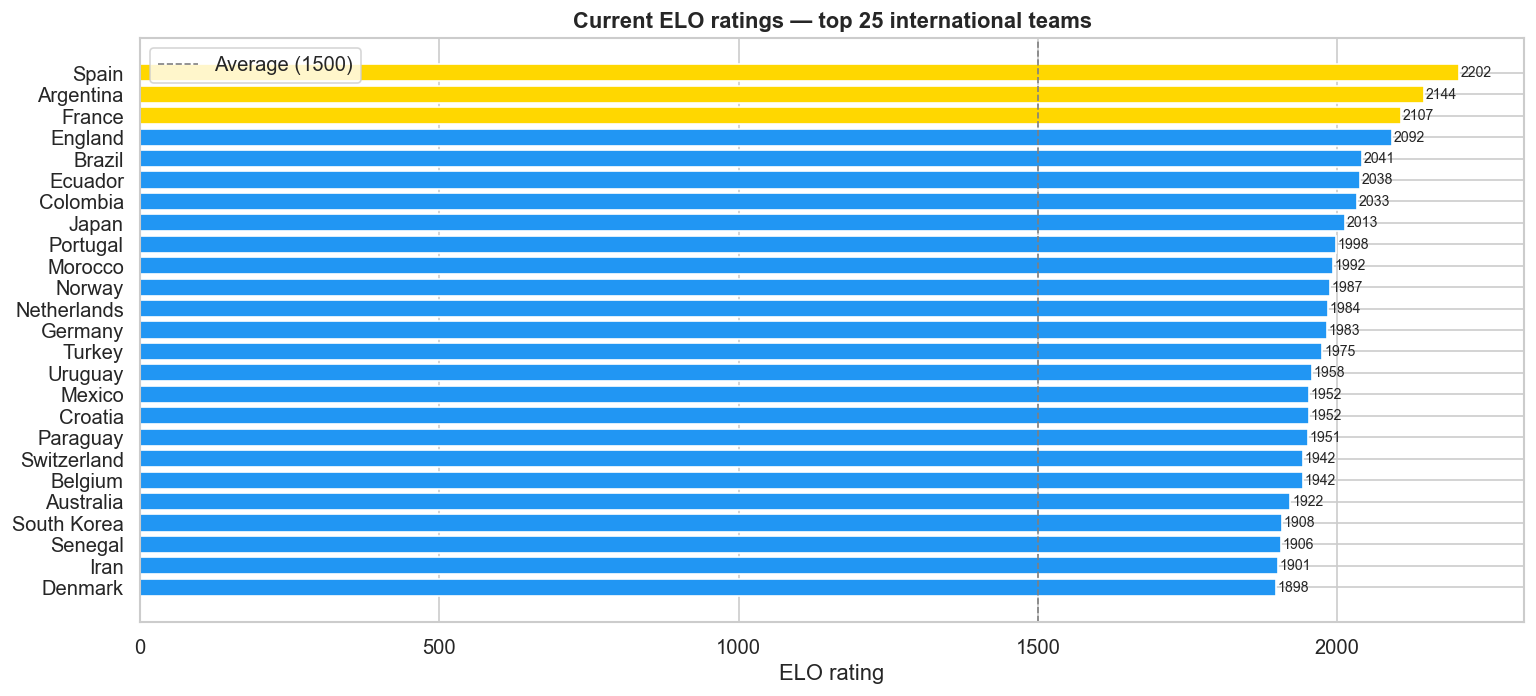

In [8]:
# Plot top 25 current ELO ratings
top25 = elo.top_n(25)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#FFD700' if i < 3 else '#2196F3' for i in range(len(top25))]
bars = ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(1500, color='gray', linestyle='--', lw=1, label='Average (1500)')
ax.set_xlabel('ELO rating')
ax.set_title('Current ELO ratings — top 25 international teams', fontweight='bold')
ax.legend()
for bar, val in zip(bars, top25.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'elo_top25.png'), bbox_inches='tight')
plt.show()


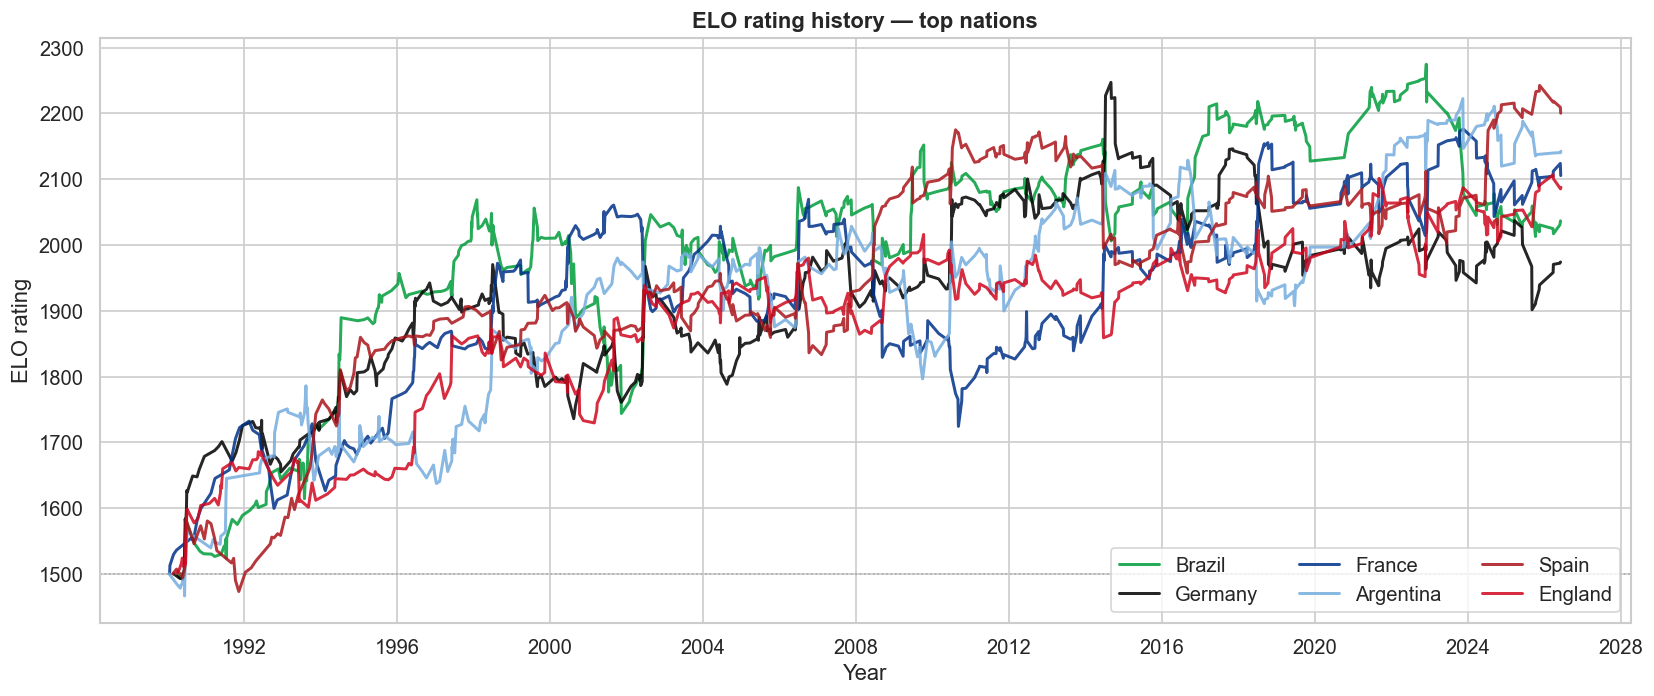

In [9]:
# ELO history for selected teams over time
elo_hist = elo.history_df()
teams_to_plot = ['Brazil', 'Germany', 'France', 'Argentina', 'Spain', 'England']
colors_map = ['#009C3B', '#000000', '#003189', '#74ACDF', '#AA151B', '#CF081F']

fig, ax = plt.subplots(figsize=(14, 6))

for team, color in zip(teams_to_plot, colors_map):
    team_data = elo_hist[elo_hist.home_team == team][['date', 'elo_home_pre']].copy()
    team_data = team_data.rename(columns={'elo_home_pre': 'elo'})
    away_data = elo_hist[elo_hist.away_team == team][['date', 'elo_away_pre']].rename(
        columns={'elo_away_pre': 'elo'})
    combined = pd.concat([team_data, away_data]).sort_values('date')
    ax.plot(combined.date, combined.elo, label=team, color=color, lw=1.8, alpha=0.85)

ax.axhline(1500, color='gray', linestyle=':', lw=1, alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('ELO rating')
ax.set_title('ELO rating history — top nations', fontweight='bold')
ax.legend(loc='lower right', ncol=3)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'elo_history.png'), bbox_inches='tight')
plt.show()


## 3. Build the full feature matrix

This is the most compute-intensive step — for each of the ~10,000 matches,
we look back in time to compute form and head-to-head features without leaking future data.

⏳ Expect ~2–5 minutes to run.


In [10]:
features = build_features(
    matches,
    elo_system=elo,
    form_window=10,
    h2h_window=10,
)

print(f'Feature matrix shape: {features.shape}')
print(f'\nOutcome distribution:')
print(features.outcome.map({2: 'home win', 1: 'draw', 0: 'away win'}).value_counts())
features.head(3)


2026-06-12 00:43:24 [INFO] src.features: Building features for 32,287 matches...
2026-06-12 01:03:26 [INFO] src.features: Feature matrix shape: (32287, 28)


Feature matrix shape: (32287, 28)

Outcome distribution:
outcome
home win    15652
away win     9045
draw         7590
Name: count, dtype: int64


,date,home_team,away_team,tournament,elo_home,elo_away,elo_diff,form_ppg_home,goals_scored_home,goals_conceded_home,...,goals_scored_diff,goals_conceded_diff,h2h_win_rate,h2h_goal_diff,h2h_n,is_neutral,tournament_weight,home_score,away_score,outcome
0,1990-01-12,Algeria,Mali,Friendly,1500.0,1500.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.5,0.0,0,1,0.333333,5,0,2
1,1990-01-14,Algeria,Cameroon,Friendly,1519.5,1500.0,19.5,3.0,5.0,0.0,...,5.0,0.0,0.5,0.0,0,1,0.333333,3,1,2
2,1990-01-17,Mexico,Argentina,Friendly,1500.0,1500.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.5,0.0,0,1,0.333333,2,0,2


In [11]:
# Check for nulls
null_counts = features[FEATURE_COLS].isnull().sum()
print('Null values per feature:')
print(null_counts[null_counts > 0] if null_counts.any() else 'None ✓')
print()
print('Feature summary statistics:')
features[FEATURE_COLS].describe().round(3)


Null values per feature:
None ✓

Feature summary statistics:


,elo_home,elo_away,elo_diff,form_ppg_home,goals_scored_home,goals_conceded_home,win_rate_home,days_since_last_home,form_ppg_away,goals_scored_away,goals_conceded_away,win_rate_away,days_since_last_away,form_diff,goals_scored_diff,goals_conceded_diff,h2h_win_rate,h2h_goal_diff,is_neutral,tournament_weight
count,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000,32287.000
mean,1579.284,1563.532,15.753,1.394,1.390,1.348,0.386,49.542,1.353,1.349,1.398,0.373,51.905,0.041,0.042,-0.050,0.417,0.071,0.282,0.590
std,220.794,218.406,235.346,0.596,0.691,0.830,0.204,133.002,0.593,0.683,0.891,0.202,137.158,0.774,0.880,1.083,0.314,1.678,0.450,0.262
min,757.345,758.601,-1296.851,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,-3.000,-15.300,-17.300,0.000,-15.000,0.000,0.333
25%,1446.241,1435.778,-119.069,1.000,0.900,0.900,0.200,4.000,1.000,0.900,0.900,0.200,4.000,-0.500,-0.500,-0.500,0.125,-0.500,0.000,0.333
50%,1576.599,1562.841,14.880,1.400,1.300,1.200,0.400,14.000,1.400,1.300,1.200,0.400,14.000,0.000,0.000,0.000,0.500,0.000,0.000,0.500
75%,1727.058,1706.777,155.680,1.800,1.700,1.600,0.500,50.000,1.800,1.700,1.700,0.500,52.000,0.600,0.600,0.500,0.500,0.700,1.000,0.833
max,2266.024,2274.860,1301.497,3.000,12.000,19.000,1.000,5796.000,3.000,21.000,19.500,1.000,5841.000,3.000,11.250,17.400,1.000,21.000,1.000,1.000


## 4. Feature correlation with outcome

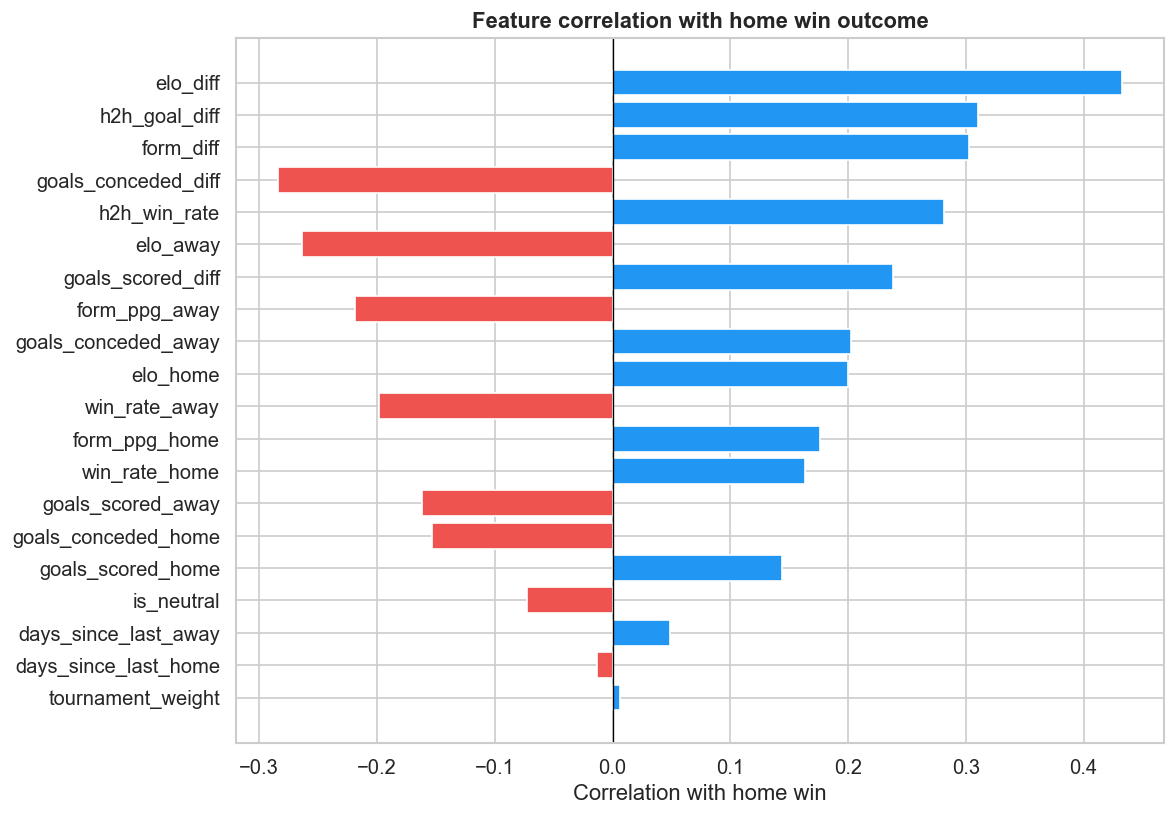

In [12]:
# Point-biserial correlation of each feature with 'home win' (binary)
home_win = (features.outcome == 2).astype(int)
correlations = features[FEATURE_COLS].corrwith(home_win).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if v > 0 else '#EF5350' for v in correlations.values]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlation with home win')
ax.set_title('Feature correlation with home win outcome', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'feature_correlations.png'), bbox_inches='tight')
plt.show()


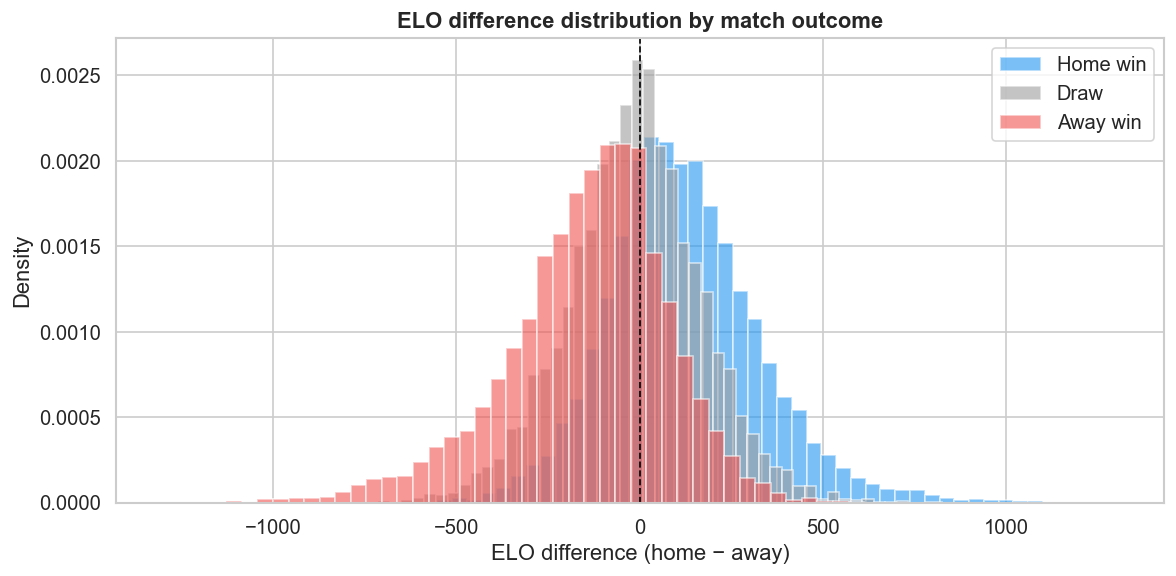

In [13]:
# ELO diff vs outcome — key predictive relationship
fig, ax = plt.subplots(figsize=(10, 5))
for outcome, label, color in [(2,'Home win','#2196F3'), (1,'Draw','#9E9E9E'), (0,'Away win','#EF5350')]:
    subset = features[features.outcome == outcome]['elo_diff']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, density=True)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_xlabel('ELO difference (home − away)')
ax.set_ylabel('Density')
ax.set_title('ELO difference distribution by match outcome', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'elo_diff_by_outcome.png'), bbox_inches='tight')
plt.show()


## 5. Save feature matrix

In [14]:
out_path = os.path.join('..', 'data', 'processed', 'features.csv')
features.to_csv(out_path, index=False)
print(f'Saved {len(features):,} rows × {len(features.columns)} columns → {out_path}')


Saved 32,287 rows × 28 columns → ../data/processed/features.csv


## ✅ Feature engineering complete

| Feature group | # features | Key insight |
|---|---|---|
| ELO ratings | 3 | Strongest single predictor |
| Recent form | 10 | Captures momentum |
| Head-to-head | 3 | Psychological edge |
| Match context | 2 | Venue and stakes matter |

**Next notebook → `03_models.ipynb`:** Train XGBoost, Random Forest, logistic regression, and Poisson models, then evaluate with cross-validation.
